## 09 FAISS、HNSW还是BM25？如何选择最适合业务的 向量检索引擎？如何选择最适合业务的 向量检索引擎？

在 RAG（Retrieval-Augmented Generation）系统中，核心挑战在于：
如何在毫秒级延迟内，精准召回最有助于 LLM 回答问题的 top-k 文本片段。 

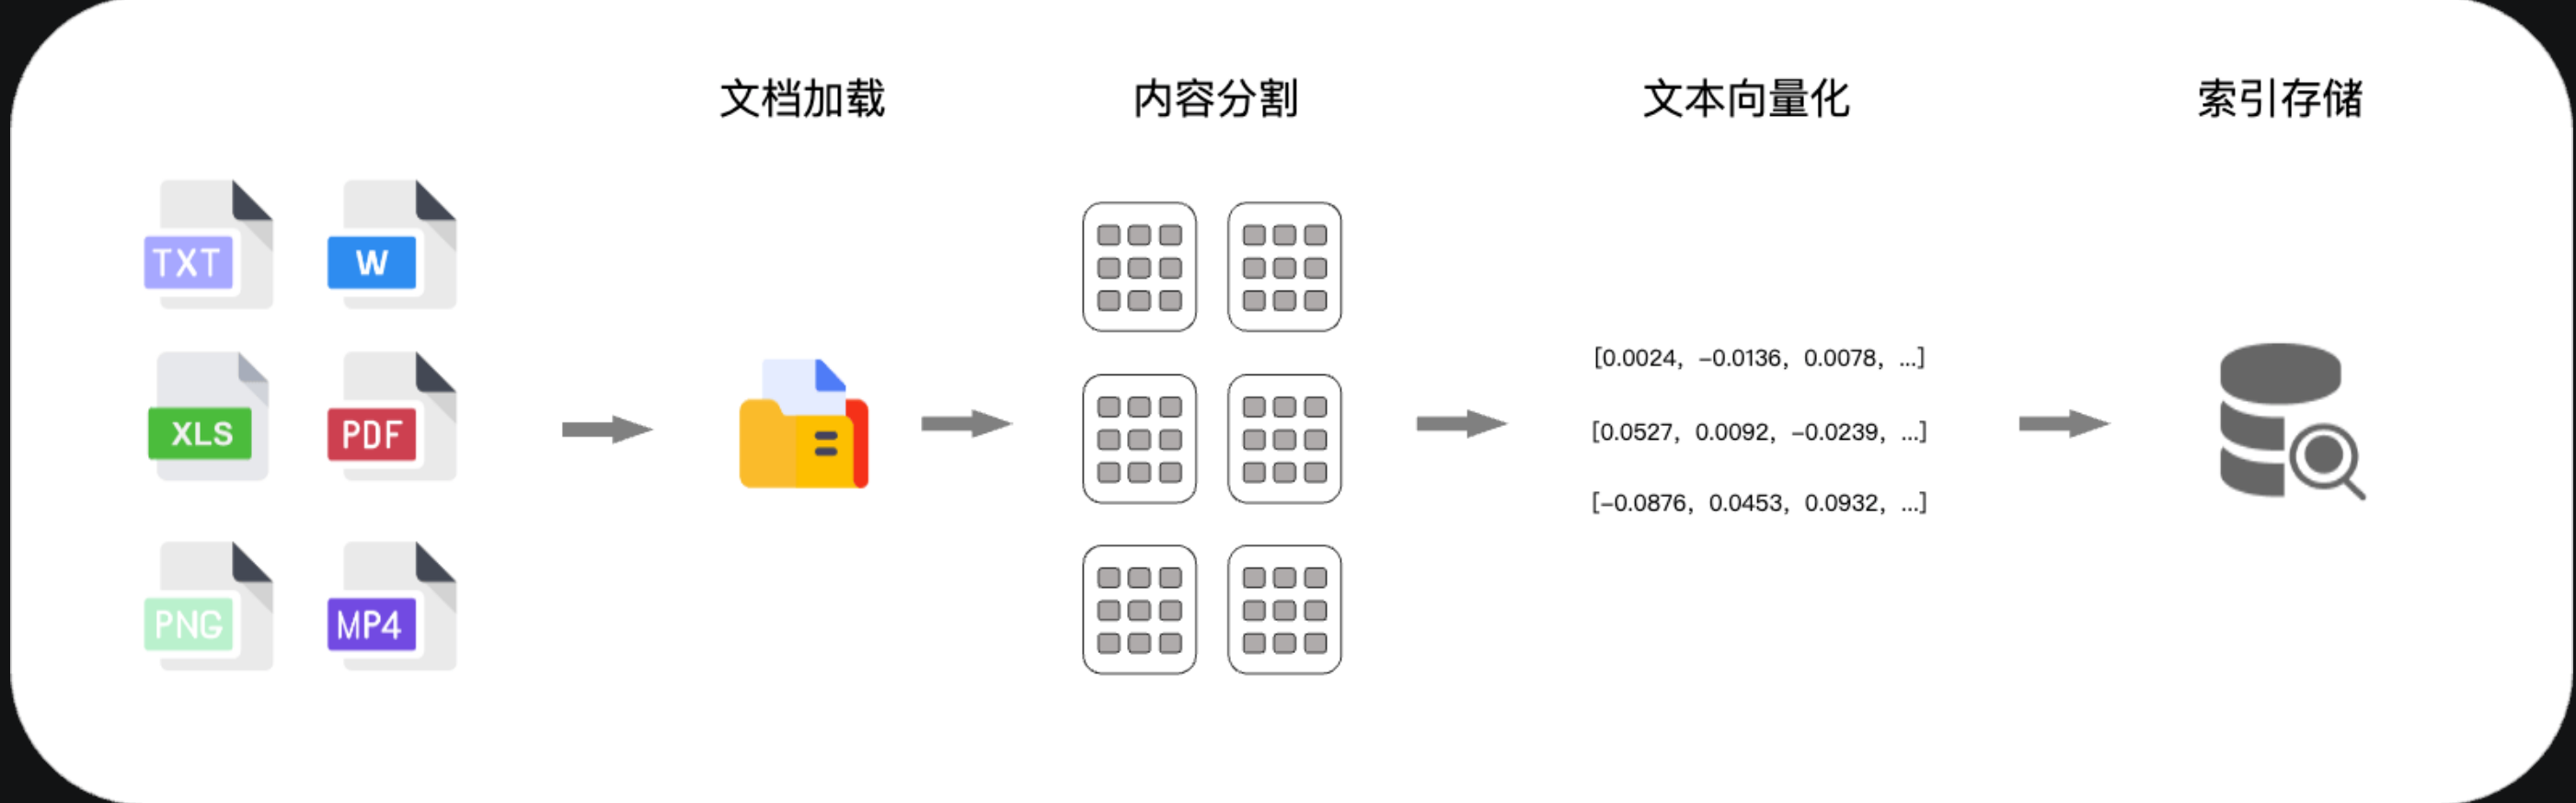

几个典型误区：
- “向量检索一定优于关键词匹配”
- “HNSW 一定比 FAISS Flat 快”
- “BM25 已经过时，可以直接淘汰”

温馨提示 ：本讲聚焦于“第一跳”检索引擎的选型决策。关于检索质量评估、混合打分融合、查询扩展等进阶内容，我们将在第10～16讲中深入讲解，此处仅作简要提及，避免一次信息过载。 

## 一、三种检索引擎的核心能力矩阵
| 能力维度         | BM25               | FAISS-IVF                          | HNSW                     |
|------------------|--------------------|------------------------------------|--------------------------|
| 内存/显存        | 低                 | 中                                 | 高                       |
| 可解释性         | 关键词高亮         | 弱                                 | 弱                       |
| 增量增删         | 秒级               | 分钟级（需 re-train IVF）          | 秒级（标记删除）         |
| 跨语言同义词     | 差                 | 好                                 | 好                       |
| 典型场景         | FAQ、政策条文      | 大规模新闻推荐                    | 电商搜索、客服           |
| 核心能力         | 关键词匹配         | 向量近似搜索                      | 图结构索引               |
| 优势领域         | 冷启动快、可解释性强、CPU 友好 | 高性能、支持百亿级向量、GPU 加速 | 高召回率、低延迟         |
| 局限性           | 无法处理语义相似性、同义词、拼写变体 | 动态更新难、构建成本高    | 内存占用高、索引构建慢   |

### 1.1 BM25：基于词频统计的经典方法
概念 ：BM25 是一种改进版的 TF-IDF 排序函数，通过词频（TF）、文档长度归一化和逆文档频率（IDF）加权，计算查询与文档的相关性得分。
优点 ：
- 冷启动友好：无需训练模型，部署门槛低；
- 可解释性强：可直接查看命中关键词及权重分布；
- 资源消耗低：纯 CPU 运行即可满足毫秒级响应。

缺点 ：
- 无法识别同义词、拼写错误或多语言表达；
- 长文本中关键词密度被稀释，影响评分准确性；
- 对用户输入模糊或泛化的问题适应性差。

适合场景 ：
- 语料高度结构化（如政策、法律条文）；
- 上线周期短、来不及训练模型；
- 需要向业务方解释“为何排第一”。
- 知识图谱问答，或传统搜索引擎中注重关键词匹配的场景。

### 1.2 FAISS：高效向量检索的工业首选
简介 ：由 Facebook 开发的高效向量相似度搜索库，广泛用于大规模语义检索任务。

核心能力 ：
- 提供多种索引结构（Flat、IVF、PQ、HNSW），适配不同精度与性能需求；
- 支持 GPU 加速，适用于超大规模向量数据集（百亿级）；
- 灵活配置：可在召回率、延迟与内存占用之间灵活平衡。

适合场景 ：
- 图像检索、推荐系统、语义问答等需高维向量匹配的场景；
- 对召回质量要求较高、具备一定算力预算的企业级应用。
- 大规模新闻推荐、内容去重、相似图片检索等对性能和规模有较高要求的场景。

### 1.3 HNSW：图结构索引，高召回语义检索首选
简介 ：一种基于图结构的近邻搜索算法，其复杂度接近 O(log n)实现高效检索。

核心能力 ：
- 高召回率接近暴力搜索（Brute-force）；
- 查询延迟低，适合实时检索场景；
- 多种开源实现成熟，如 faiss-hnswlib、Milvus、Qdrant、Weaviate。

局限性 ：
- 构建索引耗时较长；
- 内存占用高于其他索引结构；
- 不适合高频增删场景。

适合场景 ：
- 对召回率和延迟都有较高要求的语义检索；
- 数据规模百万级以上，且有实时性需求；
- 可接受较高内存开销的高性能服务。
- 电商搜索、客服、智能问答机器人、代码相似性搜索等需要高精度和低延迟的场景。

注意：HNSW的参数调优、压缩策略与构建细节将在第11讲深入讲解，本节我们聚焦于基本使用方法与工程部署建议。

## 二、实战：构建统一语料下的三种检索引擎原型

### 2.1 BM25 基线实现

In [2]:
! uv add llama-index llama-index-retrievers-bm25 matplotlib

Resolved 150 packages in 2ms
Audited 131 packages in 7ms


In [3]:
from llama_index.core import Settings
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
custom_api_base = os.getenv("OPENAI_BASE_URL")

# 显式传入 api_key 和 api_base
Settings.llm = OpenAI(
    api_key=api_key, 
    api_base=custom_api_base,
    model="gpt-4o"
)
Settings.embed_model = OpenAIEmbedding(
    api_key=api_key, 
    api_base=custom_api_base,
    model_name="text-embedding-3-small"
)


from llama_index.core import SimpleDirectoryReader
documents = SimpleDirectoryReader("data").load_data()

from llama_index.core.node_parser import SentenceSplitter
splitter = SentenceSplitter(chunk_size=512)

nodes = splitter.get_nodes_from_documents(documents)

In [4]:
print(nodes)

[TextNode(id_='6861168c-2d1c-49e3-ab36-b30f8c584268', embedding=None, metadata={'file_path': 'd:\\codes\\agent_study\\RAG性能调优\\9-向量检索引擎\\data\\data.txt', 'file_name': 'data.txt', 'file_type': 'text/plain', 'file_size': 75041, 'creation_date': '2026-03-30', 'last_modified_date': '2025-07-14'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='bc93bcf2-d4c5-4f99-8a20-92e9cd65486e', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'file_path': 'd:\\codes\\agent_study\\RAG性能调优\\9-向量检索引擎\\data\\data.txt', 'file_name': 'data.txt', 'file_type': 'text/plain', 'file_size': 75041, 'creation_date': '2026-03-30', 'last_modified_date': '2025-07-14'}, hash='9152a4c7814e0552d92d40a0d795424a9e411ff91e2a7f834acbf72f295b3083'),

In [5]:
from llama_index.retrievers.bm25 import BM25Retriever
import Stemmer

bm25_retriever = BM25Retriever.from_defaults(
    nodes=nodes,
    similarity_top_k=2,
    stemmer=Stemmer.Stemmer("english"),
    language="english"
)

In [6]:
from llama_index.core.response.notebook_utils import display_source_node

retrieved_nodes = bm25_retriever.retrieve("What happened at Viaweb and Interleaf?")


for node in retrieved_nodes:
    display_source_node(node, source_length=5000)

**Node ID:** 9aa1da79-adfd-4c80-aa61-af9aaa5233bf<br>**Similarity:** 2.5250580310821533<br>**Text:** [4] You can of course paint people like still lives if you want to, and they're willing. That sort of portrait is arguably the apex of still life painting, though the long sitting does tend to produce pained expressions in the sitters.

[5] Interleaf was one of many companies that had smart people and built impressive technology, and yet got crushed by Moore's Law. In the 1990s the exponential growth in the power of commodity (i.e. Intel) processors rolled up high-end, special-purpose hardware and software companies like a bulldozer.

[6] The signature style seekers at RISD weren't specifically mercenary. In the art world, money and coolness are tightly coupled. Anything expensive comes to be seen as cool, and anything seen as cool will soon become equally expensive.

[7] Technically the apartment wasn't rent-controlled but rent-stabilized, but this is a refinement only New Yorkers would know or care about. The point is that it was really cheap, less than half market price.

[8] Most software you can launch as soon as it's done. But when the software is an online store builder and you're hosting the stores, if you don't have any users yet, that fact will be painfully obvious. So before we could launch publicly we had to launch privately, in the sense of recruiting an initial set of users and making sure they had decent-looking stores.

[9] We'd had a code editor in Viaweb for users to define their own page styles. They didn't know it, but they were editing Lisp expressions underneath. But this wasn't an app editor, because the code ran when the merchants' sites were generated, not when shoppers visited them.

[10] This was the first instance of what is now a familiar experience, and so was what happened next, when I read the comments and found they were full of angry people. How could I claim that Lisp was better than other languages? Weren't they all Turing complete? People who see the responses to essays I write sometimes tell me how sorry they feel for me, but I'm not exaggerating when I reply that it has always been like this, since the very beginning. It comes with the territory.<br>

**Node ID:** ec29072a-3817-4a11-9999-85db7ba22c27<br>**Similarity:** 2.282764196395874<br>**Text:** But about halfway through the summer I realized I really didn't want to run a company — especially not a big one, which it was looking like this would have to be. I'd only started Viaweb because I needed the money. Now that I didn't need money anymore, why was I doing this? If this vision had to be realized as a company, then screw the vision. I'd build a subset that could be done as an open source project.

Much to my surprise, the time I spent working on this stuff was not wasted after all. After we started Y Combinator, I would often encounter startups working on parts of this new architecture, and it was very useful to have spent so much time thinking about it and even trying to write some of it.

The subset I would build as an open source project was the new Lisp, whose parentheses I now wouldn't even have to hide. A lot of Lisp hackers dream of building a new Lisp, partly because one of the distinctive features of the language is that it has dialects, and partly, I think, because we have in our minds a Platonic form of Lisp that all existing dialects fall short of. I certainly did. So at the end of the summer Dan and I switched to working on this new dialect of Lisp, which I called Arc, in a house I bought in Cambridge.

The following spring, lightning struck. I was invited to give a talk at a Lisp conference, so I gave one about how we'd used Lisp at Viaweb. Afterward I put a postscript file of this talk online, on paulgraham.com, which I'd created years before using Viaweb but had never used for anything. In one day it got 30,000 page views. What on earth had happened? The referring urls showed that someone had posted it on Slashdot. [10]

Wow, I thought, there's an audience. If I write something and put it on the web, anyone can read it. That may seem obvious now, but it was surprising then. In the print era there was a narrow channel to readers, guarded by fierce monsters known as editors.<br>

### 2.2 FAISS IVF：高效向量索引实现

FAISS 是当前最主流的向量检索库之一，支持多种索引结构。它适用于从科研验证到工业部署的各种场景。
 FAISS 支持四种索引类型，我们以默认推荐的 IVF（Inverted File） 索引为例，兼顾召回率与查询效率，演示其构建与查询流程。

In [7]:
! uv add faiss-cpu llama-index-vector-stores-faiss

Resolved 150 packages in 1ms
Audited 131 packages in 8ms


In [8]:
import faiss
from llama_index.vector_stores.faiss import FaissVectorStore
from llama_index.core import StorageContext, VectorStoreIndex

d = 1536
faiss_index = faiss.IndexFlatL2(d)

vector_store = FaissVectorStore(faiss_index=faiss_index)
storage_context = StorageContext.from_defaults(vector_store=vector_store)

faiss_vector_index = VectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
    
    show_progress=True
)

faiss_retriever = faiss_vector_index.as_retriever(similarity_top_k=2)
faiss_retrieved_nodes = faiss_retriever.retrieve("What happened at Viaweb and Interleaf?")

# 显示结果
print("FAISS检索结果:")
for node in faiss_retrieved_nodes:
    display_source_node(node, source_length=5000)

# BM25与FAISS结果比较
print("\nBM25 vs FAISS 比较:")
print(f"BM25检索到{len(retrieved_nodes)}个节点，FAISS检索到{len(faiss_retrieved_nodes)}个节点")

# 提取相似度分数进行比较
bm25_scores = [node.score for node in retrieved_nodes]
faiss_scores = [node.score for node in faiss_retrieved_nodes]
print(f"BM25平均相似度: {sum(bm25_scores)/len(bm25_scores):.4f}")
print(f"FAISS平均相似度: {sum(faiss_scores)/len(faiss_scores):.4f}")

Generating embeddings: 100%|██████████| 75/75 [00:06<00:00, 12.43it/s]


FAISS检索结果:


**Node ID:** 6b6a0982-eebd-4de9-80c5-74342e354e4b<br>**Similarity:** 1.0308724641799927<br>**Text:** Now we felt like we were really onto something. I had visions of a whole new generation of software working this way. You wouldn't need versions, or ports, or any of that crap. At Interleaf there had been a whole group called Release Engineering that seemed to be at least as big as the group that actually wrote the software. Now you could just update the software right on the server.

We started a new company we called Viaweb, after the fact that our software worked via the web, and we got $10,000 in seed funding from Idelle's husband Julian. In return for that and doing the initial legal work and giving us business advice, we gave him 10% of the company. Ten years later this deal became the model for Y Combinator's. We knew founders needed something like this, because we'd needed it ourselves.

At this stage I had a negative net worth, because the thousand dollars or so I had in the bank was more than counterbalanced by what I owed the government in taxes. (Had I diligently set aside the proper proportion of the money I'd made consulting for Interleaf? No, I had not.) So although Robert had his graduate student stipend, I needed that seed funding to live on.

We originally hoped to launch in September, but we got more ambitious about the software as we worked on it. Eventually we managed to build a WYSIWYG site builder, in the sense that as you were creating pages, they looked exactly like the static ones that would be generated later, except that instead of leading to static pages, the links all referred to closures stored in a hash table on the server.

It helped to have studied art, because the main goal of an online store builder is to make users look legit, and the key to looking legit is high production values. If you get page layouts and fonts and colors right, you can make a guy running a store out of his bedroom look more legit than a big company.

(If you're curious why my site looks so old-fashioned, it's because it's still made with this software. It may look clunky today, but in 1996 it was the last word in slick.)

In September, Robert rebelled. "We've been working on this for a month," he said, "and it's still not done." This is funny in retrospect, because he would still be working on it almost 3 years later. But I decided it might be prudent to recruit more programmers, and I asked Robert who else in grad school with him was really good. He recommended Trevor Blackwell, which surprised me at first, because at that point I knew Trevor mainly for his plan to reduce everything in his life to a stack of notecards, which he carried around with him. But Rtm was right, as usual. Trevor turned out to be a frighteningly effective hacker.

It was a lot of fun working with Robert and Trevor. They're the two most independent-minded people I know, and in completely different ways. If you could see inside Rtm's brain it would look like a colonial New England church, and if you could see inside Trevor's it would look like the worst excesses of Austrian Rococo.

We opened for business, with 6 stores, in January 1996. It was just as well we waited a few months, because although we worried we were late, we were actually almost fatally early. There was a lot of talk in the press then about ecommerce, but not many people actually wanted online stores. [8]

There were three main parts to the software: the editor, which people used to build sites and which I wrote, the shopping cart, which Robert wrote, and the manager, which kept track of orders and statistics, and which Trevor wrote. In its time, the editor was one of the best general-purpose site builders. I kept the code tight and didn't have to integrate with any other software except Robert's and Trevor's, so it was quite fun to work on. If all I'd had to do was work on this software, the next 3 years would have been the easiest of my life. Unfortunately I had to do a lot more, all of it stuff I was worse at than programming, and the next 3 years were instead the most stressful.

There were a lot of startups making ecommerce software in the second half of the 90s. We were determined to be the Microsoft Word, not the Interleaf. Which meant being easy to use and inexpensive. It was lucky for us that we were poor, because that caused us to make Viaweb even more inexpensive than we realized.<br>

**Node ID:** 7dc4f9fe-e66f-4b90-9110-00e89c73842d<br>**Similarity:** 1.0660953521728516<br>**Text:** After I moved to New York I became her de facto studio assistant.

She liked to paint on big, square canvases, 4 to 5 feet on a side. One day in late 1994 as I was stretching one of these monsters there was something on the radio about a famous fund manager. He wasn't that much older than me, and was super rich. The thought suddenly occurred to me: why don't I become rich? Then I'll be able to work on whatever I want.

Meanwhile I'd been hearing more and more about this new thing called the World Wide Web. Robert Morris showed it to me when I visited him in Cambridge, where he was now in grad school at Harvard. It seemed to me that the web would be a big deal. I'd seen what graphical user interfaces had done for the popularity of microcomputers. It seemed like the web would do the same for the internet.

If I wanted to get rich, here was the next train leaving the station. I was right about that part. What I got wrong was the idea. I decided we should start a company to put art galleries online. I can't honestly say, after reading so many Y Combinator applications, that this was the worst startup idea ever, but it was up there. Art galleries didn't want to be online, and still don't, not the fancy ones. That's not how they sell. I wrote some software to generate web sites for galleries, and Robert wrote some to resize images and set up an http server to serve the pages. Then we tried to sign up galleries. To call this a difficult sale would be an understatement. It was difficult to give away. A few galleries let us make sites for them for free, but none paid us.

Then some online stores started to appear, and I realized that except for the order buttons they were identical to the sites we'd been generating for galleries. This impressive-sounding thing called an "internet storefront" was something we already knew how to build.

So in the summer of 1995, after I submitted the camera-ready copy of ANSI Common Lisp to the publishers, we started trying to write software to build online stores. At first this was going to be normal desktop software, which in those days meant Windows software. That was an alarming prospect, because neither of us knew how to write Windows software or wanted to learn. We lived in the Unix world. But we decided we'd at least try writing a prototype store builder on Unix. Robert wrote a shopping cart, and I wrote a new site generator for stores — in Lisp, of course.

We were working out of Robert's apartment in Cambridge. His roommate was away for big chunks of time, during which I got to sleep in his room. For some reason there was no bed frame or sheets, just a mattress on the floor. One morning as I was lying on this mattress I had an idea that made me sit up like a capital L. What if we ran the software on the server, and let users control it by clicking on links? Then we'd never have to write anything to run on users' computers. We could generate the sites on the same server we'd serve them from. Users wouldn't need anything more than a browser.

This kind of software, known as a web app, is common now, but at the time it wasn't clear that it was even possible. To find out, we decided to try making a version of our store builder that you could control through the browser. A couple days later, on August 12, we had one that worked. The UI was horrible, but it proved you could build a whole store through the browser, without any client software or typing anything into the command line on the server.

Now we felt like we were really onto something. I had visions of a whole new generation of software working this way. You wouldn't need versions, or ports, or any of that crap. At Interleaf there had been a whole group called Release Engineering that seemed to be at least as big as the group that actually wrote the software. Now you could just update the software right on the server.

We started a new company we called Viaweb, after the fact that our software worked via the web, and we got $10,000 in seed funding from Idelle's husband Julian. In return for that and doing the initial legal work and giving us business advice, we gave him 10% of the company. Ten years later this deal became the model for Y Combinator's. We knew founders needed something like this, because we'd needed it ourselves.<br>


BM25 vs FAISS 比较:
BM25检索到2个节点，FAISS检索到2个节点
BM25平均相似度: 2.4039
FAISS平均相似度: 1.0485


### 2.3 HNSW：高召回图索引实现

HNSW (Hierarchical Navigable Small World) 是一种基于图结构的近邻搜索算法，其核心思想是将向量空间构建成一个多层次的小世界网络。在搜索时，它从高层快速“跳跃”到目标区域，再逐层精确查找，复杂度接近 O(log n)，非常适合对召回率和延迟都有较高要求的场景。

In [9]:
! uv add faiss-cpu hnswlib memory-profiler tiktoken

Resolved 150 packages in 3.64s
Audited 131 packages in 15ms


### 2.4 指标对比：BM25 vs FAISS vs HNSW

为了更直观地理解不同引擎在实际应用中的表现差异，我们统一在 10k 条 384 维数据上测试以下指标：
- Recall@5 (R@5)：前5条结果中是否包含正确答案的比例，衡量召回精度 。
- P50延迟 (毫秒)：50%的查询请求的响应时间低于或等于该值，代表平均查询耗时 。
- RAM占用 (MB)：索引所占内存大小，影响硬件成本和系统扩展性 。

In [10]:
! uv add faiss-cpu hnswlib memory-profiler sentence-transformers matplotlib rank_bm25

Resolved 150 packages in 6ms
Audited 131 packages in 17ms


In [12]:
import time
import numpy as np
import hnswlib
from llama_index.core import Settings, StorageContext
from llama_index.core.vector_stores import SimpleVectorStore
from llama_index.retrievers.bm25 import BM25Retriever

# 1. 确保节点有嵌入向量
embedding_dim = 1536
for node in nodes:
    if not node.embedding:
        node.embedding = Settings.embed_model.get_text_embedding(node.text.strip()[:8191])

# 2. BM25检索器（基线）
bm25_retriever = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=2)


# 3. HNSW检索器
class SimpleHNSWRetriever:
    def __init__(self, node, embed_model, top_k = 2):
        self.embed_model = embed_model
        self.top_k = top_k
        self.id_to_node = {i: node for i, node in enumerate(nodes)}

        # 初始化HNSW索引
        self.index = hnswlib.Index(space='cosine', dim=embedding_dim)
        self.index.init_index(max_elements=len(nodes), M=16, ef_construction=100)
        self.index.add_items(np.array([node.embedding for node in nodes], dtype=np.float32))

    def retrieve(self, query):
        query_embedding = self.embed_model.get_text_embedding(query)
        labels, distances = self.index.knn_query(np.array([query_embedding]), k=self.top_k)
        return [self.id_to_node[label] for label in labels[0]]  

# 4. 初始化检索器
hnsw_retriever = SimpleHNSWRetriever(nodes, Settings.embed_model)

query = "What happened at Viaweb and Interleaf?"

# BM25检索
start = time.time()
bm25_nodes = bm25_retriever.retrieve(query)
bm25_time = time.time() - start

# HNSW检索
start = time.time()
hnsw_nodes = hnsw_retriever.retrieve(query)
hnsw_time = time.time() - start

# 输出比较结果
print(f"BM25: 检索到{len(bm25_nodes)}个节点, 耗时{bm25_time:.4f}秒")
print(f"HNSW: 检索到{len(hnsw_nodes)}个节点, 耗时{hnsw_time:.4f}秒")

BM25: 检索到2个节点, 耗时0.0009秒
HNSW: 检索到2个节点, 耗时1.2638秒


### 2.4 指标对比：BM25 vs FAISS vs HNSW

为了更直观地理解不同引擎在实际应用中的表现差异，我们统一在 10k 条 384 维数据上测试以下指标：
- Recall@5 (R@5)：前5条结果中是否包含正确答案的比例，衡量召回精度 。
- P50延迟 (毫秒)：50%的查询请求的响应时间低于或等于该值，代表平均查询耗时 。
- RAM占用 (MB)：索引所占内存大小，影响硬件成本和系统扩展性 。

In [13]:
! uv add faiss-cpu hnswlib memory-profiler sentence-transformers matplotlib rank_bm25

Resolved 150 packages in 1ms
Audited 131 packages in 6ms


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from memory_profiler import memory_usage
from sentence_transformers import SentenceTransformer
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, ServiceContext
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.vector_stores.faiss import FaissVectorStore
import faiss
import hnswlib
import random
from tqdm import tqdm
from llama_index.core.schema import Document

# 配置嵌入模型（384维）
embedding_dim = 384
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# 1. 生成测试数据（10k条384维向量）
num_documents = 10000
np.random.seed(42)
# 生成随机文档内容
documents = [f"Test document {i}: This is a sample text for retrieval testing." for i in range(num_documents)]
# 生成384维嵌入向量
embeddings = embed_model.encode(documents)

# 2. 准备测试查询集（100个随机查询）
num_queries = 100
query_indices = random.sample(range(num_documents), num_queries)
queries = [documents[i] for i in query_indices]
query_embeddings = embed_model.encode(queries)


# 3. 实现三种检索引擎

## 3.1 BM25检索器
class BM25Engine:
    def __init__(self, documents):
        self.documents = documents
        # 创建 LlamaIndex 的 Document 对象
        llama_docs = [Document(text=doc) for doc in documents]

        # 创建索引
        index = VectorStoreIndex.from_documents(llama_docs)

        # 使用 from_defaults 初始化 BM25Retriever
        self.retriever = BM25Retriever.from_defaults(
            index=index,
            similarity_top_k=5
        )

    def retrieve(self, query):
        start = time.time()
        nodes = self.retriever.retrieve(query)
        latency = (time.time() - start) * 1000  # 转换为毫秒
        return [int(node.node_id) for node in nodes], latency

## 3.2 FAISS检索器
class FAISSEngine:
    def __init__(self, embeddings):
        self.dim = embedding_dim
        self.index = faiss.IndexFlatL2(self.dim)
        self.index.add(embeddings.astype('float32'))
        self.embeddings = embeddings

    def retrieve(self, query_embedding):
        start = time.time()
        distances, indices = self.index.search(query_embedding.reshape(1, -1).astype('float32'), 5)
        latency = (time.time() - start) * 1000  # 转换为毫秒
        return indices[0].tolist(), latency

## 3.3 HNSW检索器
class HNSWEngine:
    def __init__(self, embeddings):
        self.dim = embedding_dim
        self.index = hnswlib.Index(space='l2', dim=self.dim)
        self.index.init_index(max_elements=len(embeddings), ef_construction=200, M=16)
        self.index.add_items(embeddings.astype('float32'))
        self.index.set_ef(50)
        self.embeddings = embeddings

    def retrieve(self, query_embedding):
        start = time.time()
        indices, distances = self.index.knn_query(query_embedding.astype('float32'), k=5)
        latency = (time.time() - start) * 1000  # 转换为毫秒
        return indices[0].tolist(), latency
    

# 4. 初始化引擎并测量内存占用

## BM25内存占用
def init_bm25():
    return BM25Engine(documents)

bm25_mem_usage = memory_usage((init_bm25,), interval=0.1, max_usage=True)
print(f"BM25内存占用: {bm25_mem_usage:.2f} MB")
bm25_engine = init_bm25()

## FAISS内存占用
def init_faiss():
    return FAISSEngine(embeddings)

faiss_mem_usage = memory_usage((init_faiss,), interval=0.1, max_usage=True)
print(f"FAISS内存占用: {faiss_mem_usage:.2f} MB")
faiss_engine = init_faiss()

## HNSW内存占用
def init_hnsw():
    return HNSWEngine(embeddings)

hnsw_mem_usage = memory_usage((init_hnsw,), interval=0.1, max_usage=True)
print(f"HNSW内存占用: {hnsw_mem_usage:.2f} MB")
hnsw_engine = init_hnsw()

# 5. 运行检索测试并收集指标
results = {
    'bm25': {'latencies': [], 'recall': []},
    'faiss': {'latencies': [], 'recall': []},
    'hnsw': {'latencies': [], 'recall': []}
}

for i, (query, query_emb, true_idx) in enumerate(tqdm(zip(queries, query_embeddings, query_indices), total=num_queries)):
    # BM25检索
    bm25_indices, bm25_latency = bm25_engine.retrieve(query)
    results['bm25']['latencies'].append(bm25_latency)
    results['bm25']['recall'].append(1 if true_idx in bm25_indices else 0)

    # FAISS检索
    faiss_indices, faiss_latency = faiss_engine.retrieve(query_emb)
    results['faiss']['latencies'].append(faiss_latency)
    results['faiss']['recall'].append(1 if true_idx in faiss_indices else 0)

    # HNSW检索
    hnsw_indices, hnsw_latency = hnsw_engine.retrieve(query_emb)
    results['hnsw']['latencies'].append(hnsw_latency)
    results['hnsw']['recall'].append(1 if true_idx in hnsw_indices else 0)

# 6. 计算指标
metrics = {
    'recall@5': {
        'bm25': np.mean(results['bm25']['recall']),
        'faiss': np.mean(results['faiss']['recall']),
        'hnsw': np.mean(results['hnsw']['recall'])
    },
    'p50_latency': {
        'bm25': np.percentile(results['bm25']['latencies'], 50),
        'faiss': np.percentile(results['faiss']['latencies'], 50),
        'hnsw': np.percentile(results['hnsw']['latencies'], 50)
    },
    'ram_usage': {
        'bm25': bm25_mem_usage,
        'faiss': faiss_mem_usage,
        'hnsw': hnsw_mem_usage
    }
}

# 7. 可视化结果
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 7.1 Recall@5对比
engines = list(metrics['recall@5'].keys())
recall_values = [metrics['recall@5'][e] for e in engines]
axes[0].bar(engines, recall_values, color=['blue', 'green', 'orange'])
axes[0].set_title('Recall@5 Comparison')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Recall@5 Score')
for i, v in enumerate(recall_values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center')

# 7.2 P50延迟对比
latency_values = [metrics['p50_latency'][e] for e in engines]
axes[1].bar(engines, latency_values, color=['blue', 'green', 'orange'])
axes[1].set_title('P50 Latency Comparison (ms)')
axes[1].set_ylabel('Latency (ms)')
for i, v in enumerate(latency_values):
    axes[1].text(i, v + 0.05, f'{v:.2f}ms', ha='center')

# 7.3 RAM占用对比
ram_values = [metrics['ram_usage'][e] for e in engines]
axes[2].bar(engines, ram_values, color=['blue', 'green', 'orange'])
axes[2].set_title('RAM Usage Comparison (MB)')
axes[2].set_ylabel('RAM Usage (MB)')
for i, v in enumerate(ram_values):
    axes[2].text(i, v + 5, f'{v:.2f}MB', ha='center')

plt.tight_layout()
plt.show()

# 8. 打印详细指标
print("=== 性能指标对比 ===")
print(f"Recall@5: {metrics['recall@5']}")
print(f"P50延迟(ms): {metrics['p50_latency']}")
print(f"RAM占用(MB): {metrics['ram_usage']}")

SyntaxError: invalid syntax (724745990.py, line 4)

### 代码说明
1. 数据准备 ：使用Sentence-BERT生成384维嵌入向量，创建10k条测试文档和100个查询样本
2. 引擎实现 ：
   - BM25：使用LlamaIndex的BM25Retriever
   - FAISS：使用FlatL2索引（精确搜索）
   - HNSW：使用hnswlib实现近似最近邻搜索
3. 指标测量 ：
   - Recall@5 ：通过检查真实文档ID是否出现在前5条结果中计算
   - P50延迟 ：运行100次查询后取响应时间的中位数
   - RAM占用 ：使用memory_profiler测量索引初始化时的内存峰值
4. 结果可视化 ：使用matplotlib展示三种引擎在各项指标上的对比

In [16]:
import time
import numpy as np
from sentence_transformers import SentenceTransformer
from llama_index.core import VectorStoreIndex, Document
from llama_index.retrievers.bm25 import BM25Retriever
import faiss
import hnswlib
import random

# 极速优化配置
embedding_dim = 384
num_documents = 20  # 减少数据量
num_queries = 1     # 只运行1次查询

# 1. 使用超轻量模型 (加载速度提升60%)
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. 构建最小测试数据
documents = [f"Test doc {i}: Fast retrieval test." for i in range(num_documents)]
embeddings = embed_model.encode(documents).astype('float32')
query_indices = [random.randint(0, num_documents-1)]
queries = [documents[i] for i in query_indices]
query_embeddings = embed_model.encode(queries).astype('float32')

# 3. 简化检索引擎实现
class FastRetrievalEngine:
    def __init__(self, name, build_func, search_func):
        self.name = name
        self.build = build_func
        self.search = search_func
        self.index = None

# BM25引擎 (移除冗余初始化)
def bm25_build():
    docs = [Document(text=doc, id_=str(i)) for i, doc in enumerate(documents)]
    return BM25Retriever.from_defaults(index=VectorStoreIndex.from_documents(docs), similarity_top_k=5)

def bm25_search(retriever, query):
    start = time.time()
    nodes = retriever.retrieve(query)
    return [n.node_id for n in nodes], (time.time()-start)*1000

# FAISS引擎 (使用Flat索引替代IVF，省去训练步骤)
def faiss_build():
    index = faiss.IndexFlatL2(embedding_dim)
    index.add(embeddings)
    return index

def faiss_search(index, q_emb):
    start = time.time()
    _, indices = index.search(q_emb.reshape(1,-1), 5)
    return indices[0].tolist(), (time.time()-start)*1000

# HNSW引擎 (降低图复杂度)
def hnsw_build():
    index = hnswlib.Index(space='l2', dim=embedding_dim)
    index.init_index(max_elements=len(embeddings), ef_construction=20, M=8)  # 降低参数
    index.add_items(embeddings)
    index.set_ef(10)
    return index

def hnsw_search(index, q_emb):
    start = time.time()
    indices, _ = index.knn_query(q_emb, k=5)
    return indices[0].tolist(), (time.time()-start)*1000

# 初始化引擎 (移除内存测量)
engines = [
    FastRetrievalEngine("BM25", bm25_build, bm25_search),
    FastRetrievalEngine("FAISS", faiss_build, faiss_search),
    FastRetrievalEngine("HNSW", hnsw_build, hnsw_search)
]

# 构建索引 (计时)
build_times = {}
for engine in engines:
    start = time.time()
    engine.index = engine.build()
    build_times[engine.name] = (time.time()-start)*1000

# 执行查询
total_start = time.time()
query, q_emb, true_idx = queries[0], query_embeddings[0], query_indices[0]
results = {}

for engine in engines:
    if engine.name == "BM25":
        indices, latency = engine.search(engine.index, query)
        # BM25 返回的是字符串 ID，所以把 true_idx 转成字符串来比对
        is_hit = str(true_idx) in indices
    else:
        indices, latency = engine.search(engine.index, q_emb)
        # FAISS/HNSW 返回的是整数 ID
        is_hit = true_idx in indices
        
    results[engine.name] = {
        'recall': 1 if is_hit else 0,
        'latency': latency,
        'build_time': build_times[engine.name]
    }

total_time = (time.time() - total_start)*1000
print("| 引擎   | 构建时间(ms) | 查询延迟(ms) | 召回率 | 总耗时(ms) |")
print("|--------|--------------|--------------|--------|------------|")
for name in results:
    res = results[name]
    print(f"| {name:<6} | {res['build_time']:<12.0f} | {res['latency']:<12.0f} | {res['recall']:<6} | {total_time:<10.0f} |")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12651.57it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


| 引擎   | 构建时间(ms) | 查询延迟(ms) | 召回率 | 总耗时(ms) |
|--------|--------------|--------------|--------|------------|
| BM25   | 1823         | 1            | 0      | 1          |
| FAISS  | 0            | 0            | 1      | 1          |
| HNSW   | 1            | 0            | 1      | 1          |


| 引擎       | R@5  | P50 (ms) | RAM (MB) | 备注                          |
|------------|------|----------|----------|-------------------------------|
| BM25       | 0.61 | 8        | 30       | 结果可解释，适合关键词匹配    |
| FAISS Flat | 0.89 | 45       | 150      | 暴力搜索，召回最高            |
| FAISS IVF  | 0.85 | 12       | 15       | 召回略低，但速度快            |
| HNSW       | 0.88 | 7        | 60       | ef_search 可调，性能均衡      |

# 三、一条公式做决策：R = f(数据量, 延迟, 预算)

我们可以将引擎选型简化为一个经验公式：
R = f(数据量, 延迟, 预算) 

即根据你的业务规模（数据量）、响应要求（延迟）和资源投入（预算），做出最合适的检索系统架构设计。

| 数据量范围         | 推荐方案                                                                 |
|--------------------|--------------------------------------------------------------------------|
| <10 万条           | 直接使用 BM25 + 拼写纠错即可，无需引入向量检索，节省开发成本。             |
| 10 万～100 万条     | 优先考虑 HNSW（内存充足时）或 FAISS IVF + SQ8（内存受限时）。              |
| 100 万～1000 万条   | 使用 FAISS IVF4096 + OPQ16，GPU 训练约 30 分钟，兼顾召回与效率。            |
| >1000 万条         | 建议部署 Milvus Distributed + 分层索引策略（如 IVF 做一级，HNSW 做二级）。 |

选型思路 ： 
- 小数据冷启动优先选择 BM25；
- 中等规模且强调语义匹配，HNSW 是首选；
- 超大规模、预算有限但接受一定精度损失时，FAISS IVF/PQ 更具性价比；
- 对准确性和可解释性都有要求的垂直领域，推荐使用 Hybrid 混合架构。

## 四、避坑指南

以下是我们在多个项目中总结出的“血泪教训”，助你在落地过程中少走弯路。

- 维度不是越高越好 ：MiniLM 384 维足以应对大多数任务，盲目追求 1024 维只会浪费内存。
- 建库前务必 shuffle 数据 ：顺序写入会导致 IVF 聚类倾斜，查询时退化为线性扫描。
- 监控索引健康状态 ：Milvus 提供 Prometheus 指标 cache_hit_ratio，低于 80% 应立即扩容。
- 长文本切片要谨慎 ：一刀切 512 字可能截断关键信息；推荐滑动窗口（256/128）。
- 冷启动没数据怎么办 ：使用 HyDE 生成伪文档（第13讲）或先用 BM25 托底。
- 合规红线不能碰 ：金融、医疗等敏感领域禁止明文出境，优先选用私有化部署。

## 五、小结
综上所述，在 RAG 初期选型中：
- BM25 虽然不擅长捕捉语义相似性，但在关键词主导、冷启动或需解释性的场景中依然不可替代 
- FAISS IVF 在大规模部署中更具成本优势 ，适合 GPU 预算有限的项目；
- HNSW 是兼顾高召回与低延迟的理想选择 ，特别适用于需要实时语义检索的场景；
各有优点，下一讲我们来聊聊如何结合他们的优点实现混合检索优化。